In [1]:
import pymongo
from pymongo import MongoClient
import matplotlib.pyplot as plt
import numpy as np

client = MongoClient('localhost', 5001)

db = client.flask_db
annotation = db.annotation

valueToLabel = {
    1: "Idea Generation", 2: "Idea Organization", 3: "Discourse Planning",
    4: "Drafting", 5: "Lexical Chaining", 6: "Object Insertion",
    7: "Semantic", 8: "Syntactic", 9: "Lexical",
    10: "Structural", 11: "Visual", 12: "Quantitative",
    13: "Feedback", 0: "No Label", 14: "Artifact", 15: "Command Insertion",
    16: "Citation", 17: "Custom label"
}

table_size = len(valueToLabel)

project_id = "656a440644dec9f71f2dee44"

steps = [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1200, 1257]

schedule = [["lee03533@umn.edu", "chau0139@umn.edu", "rossvolkov@gmail.com"],
            ["lee03533@umn.edu", "chau0139@umn.edu", "wang9257@umn.edu"],
            ["lee03533@umn.edu", "sam", "rossvolkov@gmail.com", ],
            ["lee03533@umn.edu", "chau0139@umn.edu", "wang9257@umn.edu"],
            ["lee03533@umn.edu", "chau0139@umn.edu", "rossvolkov@gmail.com"],
            ["lee03533@umn.edu", "sam", "wang9257@umn.edu"],
            ["lee03533@umn.edu", "chau0139@umn.edu", "rossvolkov@gmail.com"],
            ["lee03533@umn.edu", "sam", "wang9257@umn.edu"],
            ["lee03533@umn.edu", "chau0139@umn.edu", "rossvolkov@gmail.com"],
            ["Nazar101@umn.edu", "sam", "wang9257@umn.edu"],
            ]


def draw_bitmap(labels):
    bitmap = []
    for i in range(len(labels)):
        row = [0] * (table_size)
        for idx in labels[i]:
            if (isinstance(idx, str) and idx.isdigit()) or isinstance(idx, int):
                row[int(idx)] = 1
            else:
                row[17] = 1
        bitmap.append(row)
    return bitmap


total_span = []
consensus_span_count = {}

In [2]:
import pandas as pd

activity = client.dataset_db.data

query = {'project_id': project_id}

cursor = activity.find(query).sort("index", pymongo.ASCENDING)

activity_df = pd.DataFrame(list(cursor))

/tmp/ipykernel_2016208/506970783.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
start_Idx = 0
for i in range(len(schedule)):

    end_Idx = start_Idx + steps[i]

    print(f"---------- {start_Idx} to {end_Idx} ----------")

    print(schedule[i][0], ",", schedule[i][1], ",", schedule[i][2])

    a1 = annotation.find_one({"annotatorEmail": schedule[i][0]})
    a2 = annotation.find_one({"annotatorEmail": schedule[i][1]})
    a3 = annotation.find_one({"annotatorEmail": schedule[i][2]})

    labels1 = a1[project_id]["filledArray"][start_Idx:end_Idx]
    labels2 = a2[project_id]["filledArray"][start_Idx:end_Idx]
    labels3 = a3[project_id]["filledArray"][start_Idx:end_Idx]

    bm1 = draw_bitmap(labels1)
    bm2 = draw_bitmap(labels2)
    bm3 = draw_bitmap(labels3)
    bms = [bm1, bm2, bm3]

    # gold_std: the array that will be used for indexing (see loop below)
    gold_std = bms[0]
    # same_arr: 0 means no consensus,
    # any other value (see valueToLabel above) means label that all three annotators agreed on
    same_arr = [0] * len(gold_std)

    # loop through the annotation data made by three annotators.
    # If all of them are the same on edit at index i, we update the label in the same_arr[i]
    for i in range(len(gold_std)):
        for j in range(len(gold_std[i])):
            if gold_std[i][j] == 1 and bms[1][i][j] == 1 and bms[2][i][j] == 1:
                same_arr[i] = j

    skip_arr = [0, 14]  # skip_arr: we ignore labels that are artifact or have no consensus
    span_arr = []   # span_arr: human-readable array that store the consensus edits span

    # Calculate the beginning and ending of each label in the array.
    # if next label does not equal to current label, we calculate the beginning and ending of current label.
    # e.g.input: [1, 1, 1, 2, 2, 2, 1, 3, 3, 3]
    # output: [["ideaGeneration", 0, 2], ["ideaOrganization", 3, 5], ["ideaGeneration", 6, 6], ["discoursePlanning", 7, 9]]
    prev_idx = 0
    for k in range(len(same_arr) - 1):
        if same_arr[k] in skip_arr:
            prev_idx = k + 1
            continue
        if same_arr[k] != same_arr[k + 1]:
            span_arr.append([valueToLabel[same_arr[k]], start_Idx + prev_idx, start_Idx + k])
            prev_idx = k + 1

    if same_arr[k+1] not in skip_arr:
            span_arr.append([valueToLabel[same_arr[k]], start_Idx + prev_idx, start_Idx + k + 1])

    print(span_arr)
    total_span.extend(span_arr)
    
    start_Idx = end_Idx

---------- 0 to 1000 ----------
lee03533@umn.edu , chau0139@umn.edu , rossvolkov@gmail.com
[['Discourse Planning', 0, 7], ['Discourse Planning', 22, 25], ['Discourse Planning', 265, 266], ['Discourse Planning', 268, 271], ['Discourse Planning', 274, 280], ['Drafting', 440, 445], ['Drafting', 449, 453], ['Drafting', 457, 467], ['Drafting', 469, 479], ['Drafting', 490, 490], ['Drafting', 495, 498], ['Drafting', 500, 501], ['Drafting', 505, 506], ['Drafting', 510, 511], ['Drafting', 515, 520], ['Drafting', 526, 557], ['Drafting', 613, 617], ['Drafting', 629, 632], ['Drafting', 769, 789], ['Structural', 838, 840], ['Structural', 853, 855], ['Drafting', 894, 906], ['Drafting', 911, 916], ['Drafting', 922, 933], ['Structural', 935, 935], ['Lexical', 948, 953]]
---------- 1000 to 2000 ----------
lee03533@umn.edu , chau0139@umn.edu , wang9257@umn.edu
[['Drafting', 1000, 1006], ['Drafting', 1009, 1028], ['Drafting', 1047, 1054], ['Drafting', 1063, 1069], ['Lexical', 1084, 1088], ['Lexical', 109

/tmp/ipykernel_2016208/1594072209.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', len(consensus_span_count))


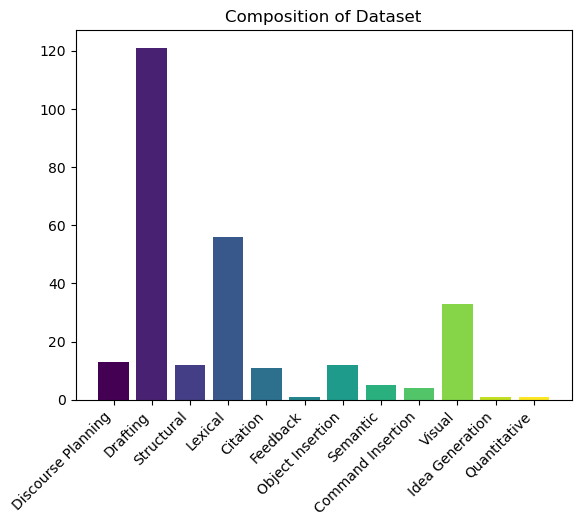

In [4]:
# this for-loop count number of data points in dataset
for each in total_span:
    label = each[0]
    if label in consensus_span_count:
        consensus_span_count[label] += 1
    else:
        consensus_span_count[label] = 1

names = list(consensus_span_count.keys())
values = list(consensus_span_count.values())

# Use a colormap
cmap = plt.cm.get_cmap('viridis', len(consensus_span_count))

# Generate colors from the colormap
colors = cmap(np.arange(len(consensus_span_count)))

plt.bar(range(len(consensus_span_count)), values, tick_label=names, color=colors)
plt.title("Composition of Dataset")
plt.xticks(rotation=45, ha='right')
plt.show()

In [5]:
# split agreement intervals on file change
true_spans = []

for [intention, start_idx, end_idx] in total_span:
  low = start_idx
  
  for i in range(start_idx + 1, end_idx + 1):
    if activity_df.iloc[low]["file"] != activity_df.iloc[i]["file"]:
      true_spans.append([intention, low, i-1])
      low = i
  
  true_spans.append([intention, low, end_idx])


In [6]:
print(len(total_span), len(true_spans))
print("-----------")
print(total_span)
print("-----------")
print(true_spans)

270 280
-----------
[['Discourse Planning', 0, 7], ['Discourse Planning', 22, 25], ['Discourse Planning', 265, 266], ['Discourse Planning', 268, 271], ['Discourse Planning', 274, 280], ['Drafting', 440, 445], ['Drafting', 449, 453], ['Drafting', 457, 467], ['Drafting', 469, 479], ['Drafting', 490, 490], ['Drafting', 495, 498], ['Drafting', 500, 501], ['Drafting', 505, 506], ['Drafting', 510, 511], ['Drafting', 515, 520], ['Drafting', 526, 557], ['Drafting', 613, 617], ['Drafting', 629, 632], ['Drafting', 769, 789], ['Structural', 838, 840], ['Structural', 853, 855], ['Drafting', 894, 906], ['Drafting', 911, 916], ['Drafting', 922, 933], ['Structural', 935, 935], ['Lexical', 948, 953], ['Drafting', 1000, 1006], ['Drafting', 1009, 1028], ['Drafting', 1047, 1054], ['Drafting', 1063, 1069], ['Lexical', 1084, 1088], ['Lexical', 1094, 1098], ['Lexical', 1115, 1117], ['Drafting', 1142, 1164], ['Drafting', 1169, 1170], ['Drafting', 1174, 1177], ['Drafting', 1184, 1184], ['Drafting', 1190, 1225

In [7]:
fine_tuning_db = client["dataset_db"]["fine_tuning"]
if True:
  fine_tuning_db.delete_many({})

In [8]:

for [intention, start_idx, end_idx] in true_spans:
  instruction = "INSTRUCTION FOR WRITING INTENTION"
  writing_intention = intention
  before_diff_arr= activity_df.iloc[start_idx]["revision"]
  after_diff_arr = activity_df.iloc[end_idx]["revision"]

  #print(writing_intention) 
  #print(before_diff_arr)
  #print(after_diff_arr)

  before_text = ""
  after_text = ""

  for arr in before_diff_arr:
    key, string = arr[:2]
    if (key == 1):
      continue
      
    before_text += string

  for arr in after_diff_arr:
    key, string = arr[:2]
    if (key == 1):
      continue

    after_text += string
  
  fine_tuning_db.insert_one({
    "instruction": instruction,
    "writing_intention": writing_intention,
    "before_text": before_text,
    "after_text": after_text,
    "diff_array": after_diff_arr,
    "start_idx": start_idx,
    "end_idx": end_idx
  })
  #print("before_text\n", before_text)
  #print("after_text\n", after_text)